In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Olist E-Commerce Revenue Leakage Analysis

**Dataset:** Olist Brazilian E-Commerce Public Dataset (Kaggle)  


In [2]:
customers = pd.read_csv(r'C:\projects_endtoend\Data Analytics Projects\revenue_leakage_analysis\data\olist_customers_dataset.csv')
geolocation = pd.read_csv(r'C:\projects_endtoend\Data Analytics Projects\revenue_leakage_analysis\data\olist_geolocation_dataset.csv')
items = pd.read_csv(r'C:\projects_endtoend\Data Analytics Projects\revenue_leakage_analysis\data\olist_order_items_dataset.csv')
payments = pd.read_csv(r'C:\projects_endtoend\Data Analytics Projects\revenue_leakage_analysis\data\olist_order_payments_dataset.csv')
reviews = pd.read_csv(r'C:\projects_endtoend\Data Analytics Projects\revenue_leakage_analysis\data\olist_order_reviews_dataset.csv')
orders = pd.read_csv(r'C:\projects_endtoend\Data Analytics Projects\revenue_leakage_analysis\data\olist_orders_dataset.csv')
products = pd.read_csv(r'C:\projects_endtoend\Data Analytics Projects\revenue_leakage_analysis\data\olist_products_dataset.csv')
sellers  = pd.read_csv(r'C:\projects_endtoend\Data Analytics Projects\revenue_leakage_analysis\data\olist_sellers_dataset.csv')
category = pd.read_csv(r'C:\projects_endtoend\Data Analytics Projects\revenue_leakage_analysis\data\product_category_name_translation.csv')

print('datasets loaded successfully')

datasets loaded successfully


In [3]:
datasets = {'customers': customers, 'geolocation': geolocation, 'items': items, 'payments': payments, 
            'reviews': reviews, 'orders': orders, 'products': products, 'sellers': sellers, 'category': category}

for name,data in datasets.items():
    print(name,':', data.shape)

customers : (99441, 5)
geolocation : (1000163, 5)
items : (112650, 7)
payments : (103886, 5)
reviews : (99224, 7)
orders : (99441, 8)
products : (32951, 9)
sellers : (3095, 4)
category : (71, 2)


In [4]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


## Null Value Check 

In [5]:
for name, data in datasets.items():
    null_cols = data.isna().sum()
    null_cols = null_cols[null_cols > 0]

    if len(null_cols) > 0:
        print(f"\n{name}:")
        print(null_cols)
        print('-----------------------------')



reviews:
review_comment_title      87656
review_comment_message    58247
dtype: int64
-----------------------------

orders:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64
-----------------------------

products:
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64
-----------------------------


* reviews, orders, products datasets have null values

* Null values in review_comment_title and review_comment_message are expected because many customers provide only a star rating without written feedback. These missing values do not indicate data quality issues and are not directly related to revenue leakage

## Review Score Analysis

In [6]:
print('avg review score:', round(reviews['review_score'].mean(),2))
print('% of 5 star reviews:', round((reviews['review_score']==5).mean() * 100,2))
print('% of 1 star reviews:', round((reviews['review_score']==1).mean() * 100,2))
print('% of 2 star reviews:', round((reviews['review_score']<=2).mean() * 100,2))

avg review score: 4.09
% of 5 star reviews: 57.78
% of 1 star reviews: 11.51
% of 2 star reviews: 14.69


* Low review scores are treated as a leading indicator of potential revenue leakage because dissatisfied customers are more likely to reduce repeat purchases, increase return rates, and negatively impact future sales through poor customer experience.

## Orders Null Check

### Why are these null?
* order_approved_at null = payment not approved (likely failed/cancelled orders)
* order_delivered_carrier_date null = never picked up by carrier
* order_delivered_customer_date null = never reached customer
* These nulls are NOT random — they directly map to revenue leakage

* Missing values in delivery timestamps are business-event driven rather than random. They typically correspond to cancelled, unavailable, or incomplete orders and therefore represent potential operational or revenue leakage points.

## Order Status Analysis

In [7]:
orders['order_status'].value_counts()


order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

### realized revenue = delivered orders. 

(Revenue is only counted once an order is successfully delivered to the customer.

Any orders that are canceled, returned, or still in transit are not included in realized revenue.

The logic is: until the product reaches the customer, the company cannot truly “realize” or confirm that revenue.)

* Delivered: Realized revenue baseline used throughout the analysis.
* Canceled: Direct revenue loss due to failed transactions.
* Unavailable: Potential revenue leakage caused by inventory or operational issues.
* Shipped / Invoiced / Processing: Orders still in the fulfillment pipeline and therefore excluded from realized revenue calculations.

## Cancelled Orders Analysis

In [8]:
cancelled = orders[orders['order_status']=='canceled'].shape[0]
total = orders.shape[0]
print('cancellation rate:', round(cancelled/total * 100,2), '%')

cancellation rate: 0.63 %


* Cancellation rate is used as a direct revenue leakage metric because every cancelled order represents lost realized revenue and additional operational costs.

In [30]:
canceled_revenue = df.loc[df['order_status'] == 'canceled', 'price'].sum()
print('Revenue lost from canceled orders:', round(canceled_revenue,2))

Revenue lost from canceled orders: 95235.27


## Products Null Check

* 610 products have no category name — these cannot be analyzed by category
* Portuguese category names are mapped to English using the official translation table provided in the Olist dataset
* Remaining nulls will be labeled 'Unknown' during EDA

# Freight Analysis

In [9]:
print(items[['freight_value','price']].describe())


       freight_value          price
count  112650.000000  112650.000000
mean       19.990320     120.653739
std        15.806405     183.633928
min         0.000000       0.850000
25%        13.080000      39.900000
50%        16.260000      74.990000
75%        21.150000     134.900000
max       409.680000    6735.000000


In [10]:
print('total revenue:', round(items['price'].sum(),2))
print('total freight value:', round(items['freight_value'].sum(),2))
print('freight % of total revenue:', round(items['freight_value'].sum() / items['price'].sum() * 100, 2))

total revenue: 13591643.7
total freight value: 2251909.54
freight % of total revenue: 16.57


In [11]:
items

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


In [12]:
delivered_ids = orders[orders['order_status']=='delivered']['order_id']
delivered_items = items[items['order_id'].isin(delivered_ids)]

print("Delivered items revenue:", round(delivered_items['price'].sum(),2))
print('Delivered items freight cost:', round(delivered_items['freight_value'].sum(),2))
print('Freight % of delivered items revenue:', round(delivered_items['freight_value'].sum()/delivered_items['price'].sum() * 100, 2))

Delivered items revenue: 13221498.11
Delivered items freight cost: 2198275.64
Freight % of delivered items revenue: 16.63


* Freight is a cost passed to the customer. 

* Gross product revenue is R$13M. Freight costs account for approximately 16.6% of total product revenue. Categories with unusually high freight-to-price ratios may experience margin compression, making logistics costs a significant source of revenue leakage."

* Example: A product priced at R$50 but freight charged at R$60.

* In such cases, the company earns almost nothing (near‑zero margin) or even loses money (negative margin).

## Payments Analysis

In [13]:
print(payments['payment_type'].value_counts())
print('='*50)
print(payments['payment_installments'].max())
print('='*50)
print(payments['payment_value'].describe())

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64
24
count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64


* Max 24 installments observed. Orders with a high number of payment installments may indicate elevated financial risk. This hypothesis was explored further by comparing installment patterns with order cancellations. 


In [14]:
high_install = payments[payments['payment_installments'] >= 6]['order_id']
high_install_cancel_rate = orders[orders['order_id'].isin(high_install)]['order_status'].value_counts()
print('Cancellation rate for orders with 6 or more installments:', high_install_cancel_rate['canceled'])

Cancellation rate for orders with 6 or more installments: 101


## Late Delivery Analysis

In [15]:
orders.head(2)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00


In [16]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

delivered = orders[orders['order_status'] == 'delivered'].copy()
delivered['delay_days'] = (delivered['order_delivered_customer_date'] - delivered['order_estimated_delivery_date']).dt.days

late_deliveries = delivered[delivered['delay_days'] > 0]
print('Late deliveries:', len(late_deliveries), (round(len(late_deliveries)/len(delivered) * 100,2), '%'))
print('Average Delay:', round(late_deliveries['delay_days'].mean(), 0), 'days')
print('Max Delay:', late_deliveries['delay_days'].max(), 'days')


Late deliveries: 6534 (6.77, '%')
Average Delay: 11.0 days
Max Delay: 188.0 days


* Late deliveries emerged as one of the strongest operational leakage indicators due to their association with lower customer satisfaction and reduced service quality.

## Freight Ratio Per Order

In [17]:
order_freight = delivered_items.groupby('order_id').agg(total_price=('price','sum'), 
                                                       total_freight=('freight_value','sum')).reset_index()
order_freight['freight_ratio'] = order_freight['total_freight'] / order_freight['total_price']

highest_freight = order_freight[order_freight['freight_ratio'] >= 0.4]

print("orders with freight cost >= 40% of total price:", len(highest_freight))
print("That's", round(len(highest_freight)/len(order_freight) * 100,2),"% of delivered orders")
print("Revenue at risk from these orders:", round(highest_freight['total_price'].sum(),2))

orders with freight cost >= 40% of total price: 22165
That's 22.97 % of delivered orders
Revenue at risk from these orders: 952253.51


# Leakage 1 - Late Delivery Deep Dive

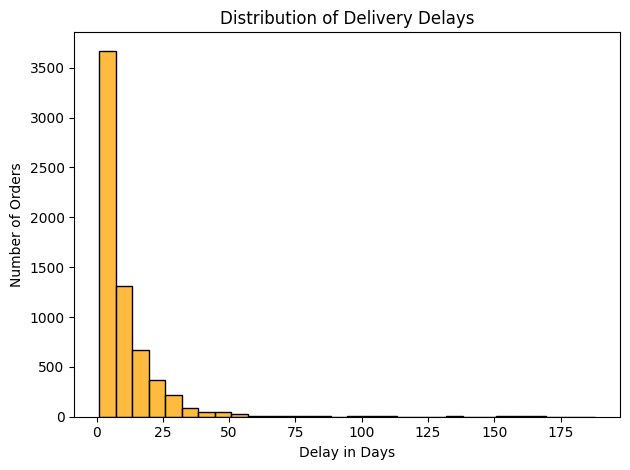

In [18]:
sns.histplot(late_deliveries['delay_days'], bins=30, color='orange')
plt.title('Distribution of Delivery Delays')
plt.xlabel('Delay in Days')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

In [19]:
late_deliveries_with_reviews = late_deliveries.merge(reviews[['order_id','review_score']], on='order_id', how='left')
on_time_deliveries_with_reviews = delivered[delivered['delay_days'] <= 0].merge(reviews[['order_id','review_score']], on='order_id', how='left')

print('Average review score for late deliveries:', round(late_deliveries_with_reviews['review_score'].mean(),2))
print('Average review score for on-time deliveries:', round(on_time_deliveries_with_reviews['review_score'].mean(),2))

Average review score for late deliveries: 2.27
Average review score for on-time deliveries: 4.29


* The analysis shows a negative relationship between delivery delays and customer review scores, suggesting that longer delays are associated with lower customer satisfaction.

# Leakage 2- High Freight Ratio Deep Dive

In [20]:
# Merging delivered items with product and category info for deeper analysis

items_products = delivered_items.merge(products, on='product_id', how='left')
items_products = items_products.merge(category, on='product_category_name', how='left')

items_products.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools


In [21]:
category_freight = items_products.groupby('product_category_name_english').agg(
    avg_price=('price','mean'), avg_freight=('freight_value','mean')).reset_index()

category_freight['freight_ratio'] = category_freight['avg_freight'] / category_freight['avg_price']
category_freight = category_freight.sort_values('freight_ratio', ascending=False).head(10)
category_freight

,product_category_name_english,avg_price,avg_freight,freight_ratio
46,home_comfort_2,25.342333,13.677000,0.539690
35,flowers,33.637576,14.814242,0.440408
41,furniture_mattress_and_upholstery,116.848108,42.739730,0.365772
12,christmas_supplies,58.252267,21.272733,0.365183
23,diapers_and_hygiene,40.561892,14.740541,0.363409
11,cds_dvds_musicals,52.142857,16.070714,0.308205
62,signaling_and_security,108.198223,32.880914,0.303895
26,electronics,56.813459,16.738424,0.294621
37,food_drink,55.549740,16.337881,0.294113
25,dvds_blu_ray,74.468689,20.118852,0.270165


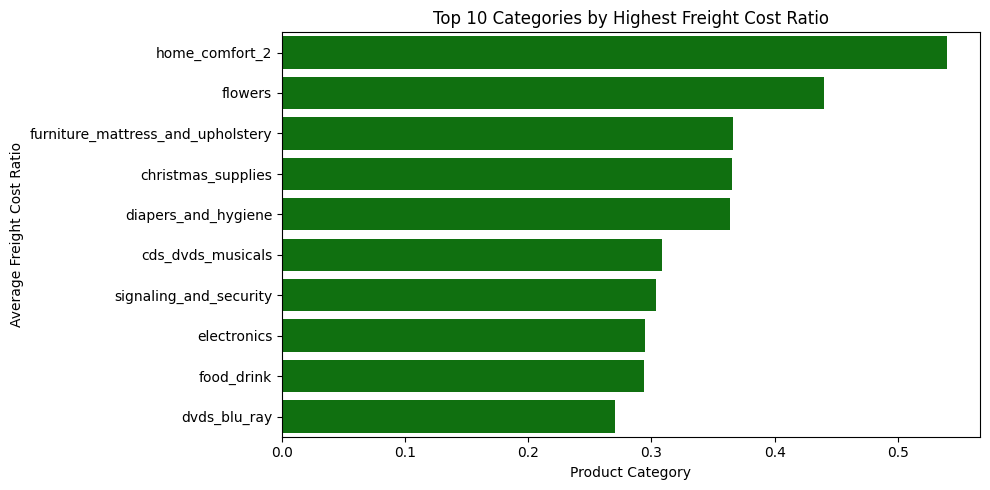

In [22]:
plt.figure(figsize=(10,5))
sns.barplot(data=category_freight, x='freight_ratio', y='product_category_name_english', color='green')
plt.title('Top 10 Categories by Highest Freight Cost Ratio')
plt.xlabel('Product Category')
plt.ylabel('Average Freight Cost Ratio')
plt.tight_layout()
plt.show()

* Categories with consistently high freight-to-price ratios may contribute to revenue leakage by reducing effective margins and making products less price competitive.

# Leakage 3 - Seller Performance Analysis

In [23]:
# merge delivered items with orders and reviews to analyze seller performance

seller_analysis = delivered_items.merge(orders[['order_id']], on='order_id', how='left').merge(
    reviews[['order_id','review_score']], on='order_id', how='left')

seller_stats = seller_analysis.groupby('seller_id').agg(
    total_revenue=('price','sum'), total_orders=('order_id','count'), avg_review=('review_score','mean')
).reset_index()

seller_stats.head()

,seller_id,total_revenue,total_orders,avg_review
0,0015a82c2db000af6aaaf3ae2ecb0532,2685.00,3,3.666667
1,001cca7ae9ae17fb1caed9dfb1094831,24487.03,234,3.965368
2,002100f778ceb8431b7a1020ff7ab48f,1236.50,55,4.036364
3,003554e2dce176b5555353e4f3555ac8,120.00,1,5.000000
4,004c9cd9d87a3c30c522c48c4fc07416,20324.20,174,4.145349


In [24]:
seller_stats['is_bad_seller'] = seller_stats['avg_review'] < 3

bad_sellers = seller_stats[seller_stats['is_bad_seller']]

print('Number of bad sellers with avg review < 3:', len(bad_sellers))
print('Total revenue from bad sellers:', round(bad_sellers['total_revenue'].sum(),2))
print('% of total revenue from bad sellers:', round(bad_sellers['total_revenue'].sum() / seller_stats['total_revenue'].sum() * 100,2), '%')

Number of bad sellers with avg review < 3: 186
Total revenue from bad sellers: 264901.62
% of total revenue from bad sellers: 1.99 %


* 186 sellers with review scores below 3 (6% of all sellers) account for $2.64M in revenue (2% of total). These low-performing sellers drive potential future revenue loss and customer churn through cancellations and negative reviews, representing actionable risk concentration.

# Business Summary

In [36]:
total_revenue = delivered_items['price'].sum()

# leakage 1 - late deliveries leading to bad reviews and customer churn
late_order_ids = late_deliveries['order_id']
late_deliveries_revenue = delivered_items[delivered_items['order_id'].isin(late_order_ids)]['price'].sum()

# leakage 2 - high freight cost orders leading to customer dissatisfaction
high_freight_revenue = order_freight[order_freight['freight_ratio'] >= 0.4]['total_price'].sum()

# leakage 3 - bad sellers with low reviews causing customer churn
bad_seller_ids = bad_sellers['seller_id']
bad_seller_revenue = delivered_items[delivered_items['seller_id'].isin(bad_seller_ids)]['price'].sum()

print('=' * 70)
print("REVENUE LEAKAGE SUMMARY:")
print('=' * 70)
print(f"Total Revenue: ${round(total_revenue,2)}")
print(f"leakage 1 - Late Deliveries Revenue at Risk: ${round(late_deliveries_revenue,2)} ({round(late_deliveries_revenue/total_revenue * 100,2)}%)")
print(f"leakage 2 - High Freight Orders Revenue at Risk: ${round(high_freight_revenue,2)} ({round(high_freight_revenue/total_revenue * 100,2)}%)")
print(f"leakage 3 - Bad Sellers Revenue at Risk: ${round(bad_seller_revenue,2)} ({round(bad_seller_revenue/total_revenue * 100,2)}%)")
print('=' * 70)

REVENUE LEAKAGE SUMMARY:
Total Revenue: $13221498.11
leakage 1 - Late Deliveries Revenue at Risk: $985924.34 (7.46%)
leakage 2 - High Freight Orders Revenue at Risk: $952253.51 (7.2%)
leakage 3 - Bad Sellers Revenue at Risk: $263972.44 (2.0%)


#### *Revenue leakage in this project refers to realized or potential revenue loss arising from operational inefficiencies, including order cancellations, high freight costs, delivery delays, and poor customer experience indicators.*

In [32]:
orders.merge(items, on='order_id', how='left').groupby(orders['order_status']=='delivered')['price'].sum()

order_status
False      341497.24
True     11594356.28
Name: price, dtype: float64

In [34]:
df = orders.merge(items, on='order_id', how='left')
round(df[df['order_status']=='delivered']['price'].sum(),2)

np.float64(13221498.11)